# Exploratory data analysis|

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
#Load Data
import kagglehub
path = kagglehub.dataset_download("anthonytherrien/depression-dataset")
print("Path to dataset files:", path)

100%|██████████| 8.69M/8.69M [00:02<00:00, 3.57MB/s]

Extracting files...


Path to dataset files: /Users/lalunamacbookpro/.cache/kagglehub/datasets/anthonytherrien/depression-dataset/versions/1


In [3]:
df = pd.read_csv(path + "/depression_data.csv")
df.head()

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


## Checking the row whether each row is distinct, and giving a unqilo Record_ID number.

In [ ]:
# Check for completely duplicated rows across all columns
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions,Person_Key


In [ ]:
# Combine Name and Age to create a unique identifier for each person
df["Person_Key"] = (
    df["Name"].astype(str).str.replace(" ", "_") 
    + "_" 
    + df["Age"].astype(str)
)

df["Person_Key"].nunique()

395794

In [21]:
df["Person_Key"].duplicated().sum()

np.int64(17974)

However, Name+age is not sufficent to uniquely identify a person, as there are some duplicate Person_Keys. Then I'll genrate a unique number for each row and the call it Record ID.

In [26]:
# Assign a unique record ID starting from 100000
df = df.drop(columns=["Person_Key"])
df["Record_ID"] = range(100000, 100000 + len(df))
df.head()

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions,Record_ID
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes,100000
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes,100001
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No,100002
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No,100003
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes,100004


I would like to use modelo 60 to random select train, validate and test dataset, and split them with propotion 60:20:20. I will use train dataset on exploring data, selecting model, and tunning my hps. And use validate set to decide on the final model, where as the test set will keep unseen during all tarinning processes, and used to get the unbiased result of the best performing model.

## Target analysis and Feature vs Target plots

In [32]:
df["data_split"] = df["Record_ID"].apply(
    lambda x: "train" if x % 60 < 36
    else "validation" if x % 60 < 48
    else "test"
)
df["data_split"].value_counts()

data_split
train         248256
validation     82760
test           82752
Name: count, dtype: int64

In [ ]:
# Replace spaces with _ for all column names
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['Name', 'Age', 'Marital_Status', 'Education_Level',
       'Number_of_Children', 'Smoking_Status', 'Physical_Activity_Level',
       'Employment_Status', 'Income', 'Alcohol_Consumption', 'Dietary_Habits',
       'Sleep_Patterns', 'History_of_Mental_Illness',
       'History_of_Substance_Abuse', 'Family_History_of_Depression',
       'Chronic_Medical_Conditions', 'Record_ID', 'data_split'],
      dtype='str')

In [ ]:
exclude_cols = ["Name", "Record_ID", "data_split", "History_of_Mental_Illness"]
features = [col for col in df.columns if col not in exclude_cols]
print(features)

['Age', 'Marital_Status', 'Education_Level', 'Number_of_Children', 'Smoking_Status', 'Physical_Activity_Level', 'Employment_Status', 'Income', 'Alcohol_Consumption', 'Dietary_Habits', 'Sleep_Patterns', 'History_of_Substance_Abuse', 'Family_History_of_Depression', 'Chronic_Medical_Conditions']


In [73]:
#Get a summary of the target variable for each datasplit.
summary_df = (
    df.groupby("data_split")["History_of_Mental_Illness"]
    .value_counts()
    .unstack(fill_value=0)
)

summary_df["Total"] = summary_df.sum(axis=1)
summary_df["Yes Rate (%)"] = (
    summary_df["Yes"] / summary_df["Total"] * 100
).round(2)

summary_df

History_of_Mental_Illness,No,Yes,Total,Yes Rate (%)
data_split,,,,
test,57693,25059,82752,30.28
train,172443,75813,248256,30.54
validation,57807,24953,82760,30.15


So the target is about 30% positive and 70% negative, which is not imbalanced.In later modelling process, we can look at multiple metrics.

In [44]:
# Summary statistics for numerical features
df[df["data_split"] == "train"][features].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,248256.0,NaN,NaN,NaN,49.023746,18.146466,18.0,33.0,49.0,65.0,80.0
Marital_Status,248256,4,Married,144230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,248256,5,Bachelor's Degree,74698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number_of_Children,248256.0,NaN,NaN,NaN,1.299687,1.236685,0.0,0.0,1.0,2.0,4.0
Smoking_Status,248256,3,Non-smoker,148751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Physical_Activity_Level,248256,3,Sedentary,105881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment_Status,248256,2,Employed,159230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,248256.0,NaN,NaN,NaN,50594.530989,40575.727557,0.52,20969.455,37494.38,76419.57,209995.22
Alcohol_Consumption,248256,3,Moderate,103865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dietary_Habits,248256,3,Unhealthy,102320,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We can see from this summarise, only 2 features are numerical, and rests are categorical data. Let's split feature into two list.

In [51]:
numeric_features = ["Age", "Income"]
categorical_features = df[df["data_split"] == "train"][features].select_dtypes(
    include=["object", "category"]
).columns.tolist()
categorical_features.append("Number_of_Children")
categorical_features

/var/folders/wh/mcjq580j09j41w3vqk9sxwd80000gn/T/ipykernel_21869/1508790804.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df[df["data_split"] == "train"][features].select_dtypes(


['Marital_Status',
 'Education_Level',
 'Smoking_Status',
 'Physical_Activity_Level',
 'Employment_Status',
 'Alcohol_Consumption',
 'Dietary_Habits',
 'Sleep_Patterns',
 'History_of_Substance_Abuse',
 'Family_History_of_Depression',
 'Chronic_Medical_Conditions',
 'Number_of_Children']

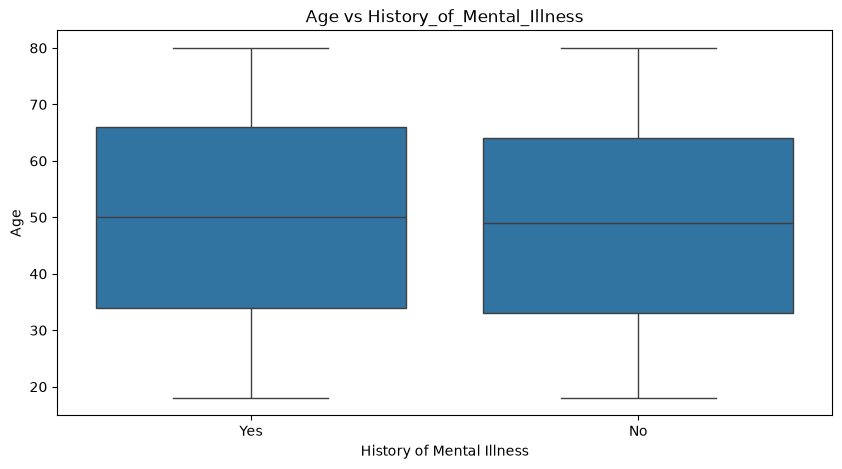

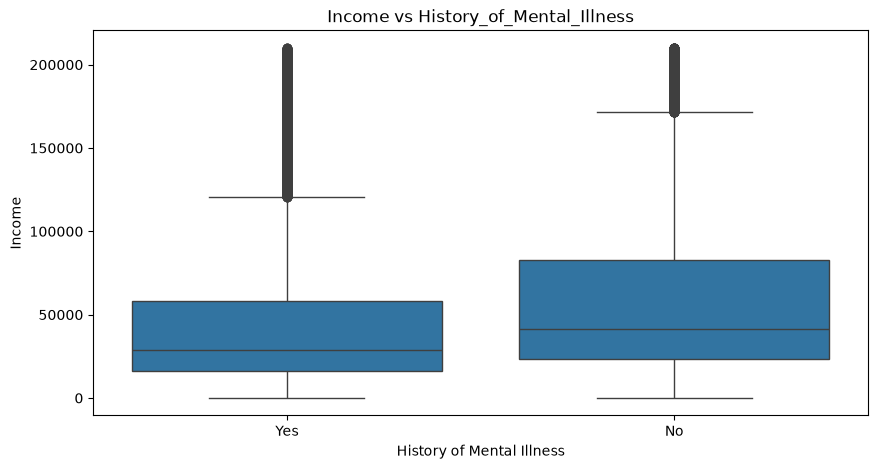

In [69]:
for feature in numeric_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df[df["data_split"] == "train"], x="History_of_Mental_Illness", y=feature)
    
    plt.title(f"{feature} vs History_of_Mental_Illness")
    plt.xlabel("History of Mental Illness")
    plt.ylabel(feature)
    plt.show()

In [82]:
for feature in numeric_features:
    print(feature)
    print("Skewness:", df[df["data_split"] == "train"][feature].skew())
    print()

Age
Skewness: -0.001200915635174852

Income
Skewness: 1.087293410850627



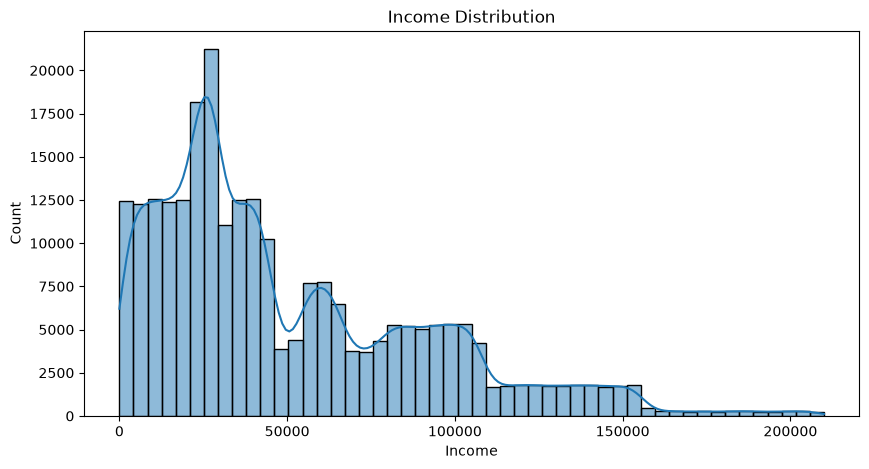

In [87]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=(df[df["data_split"] == "train"]),
    x="Income",
    bins=50,
    kde=True
)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

In [80]:
categorical_summary = []

for feature in categorical_features:
    counts = (df[df["data_split"] == "train"][feature].value_counts())
    percentages = (df[df["data_split"] == "train"][feature].value_counts(normalize=True).mul(100).round(2))

    for category in counts.index:
        categorical_summary.append({
            "Feature": feature,
            "Category": category,
            "Count": counts[category],
            "Percentage (%)": percentages[category]
        })

In [81]:
categorical_summary_df = pd.DataFrame(categorical_summary)
categorical_summary_df

,Feature,Category,Count,Percentage (%)
0,Marital_Status,Married,144230,58.10
1,Marital_Status,Single,43163,17.39
2,Marital_Status,Widowed,41186,16.59
3,Marital_Status,Divorced,19677,7.93
4,Education_Level,Bachelor's Degree,74698,30.09
5,Education_Level,High School,71396,28.76
6,Education_Level,Associate Degree,47945,19.31
7,Education_Level,Master's Degree,44223,17.81
8,Education_Level,PhD,9994,4.03
9,Smoking_Status,Non-smoker,148751,59.92


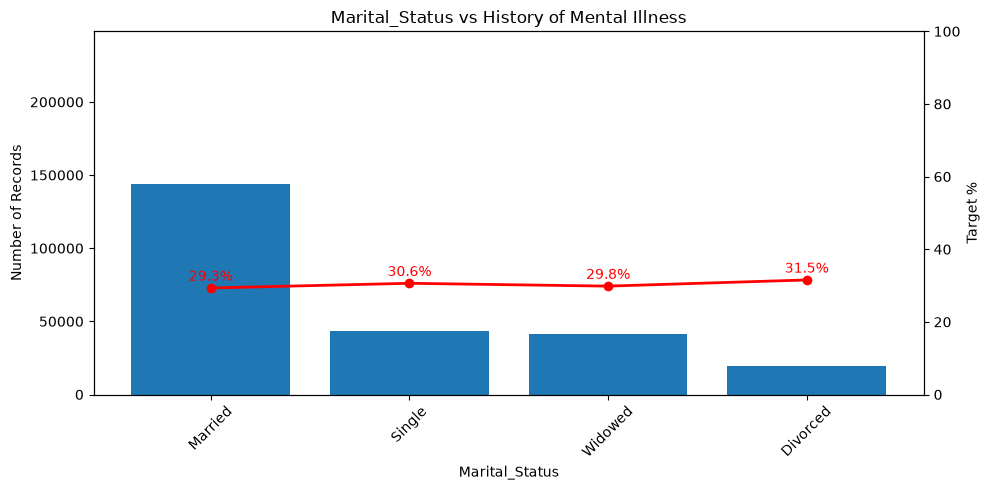

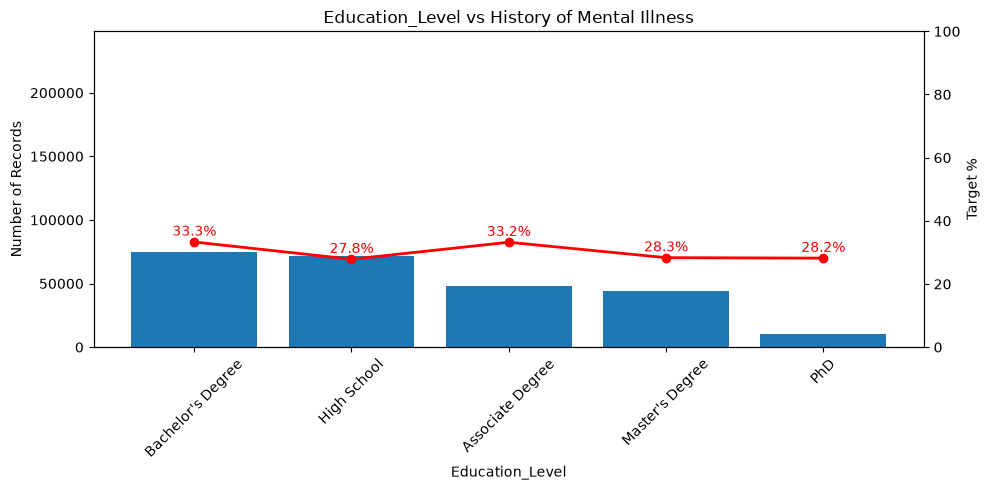

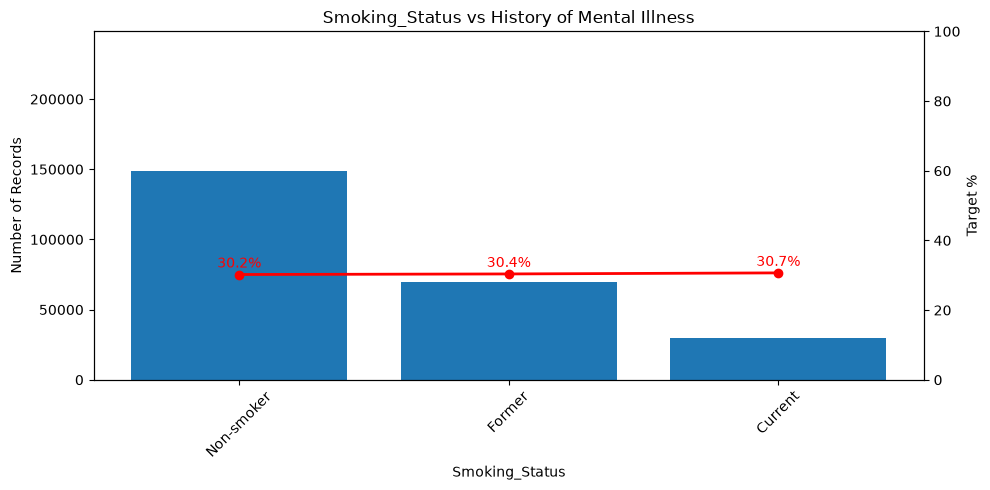

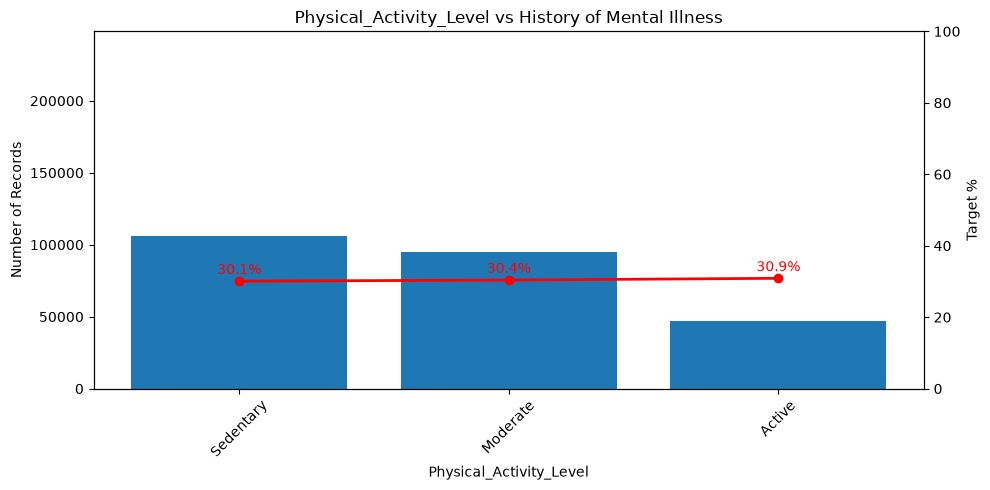

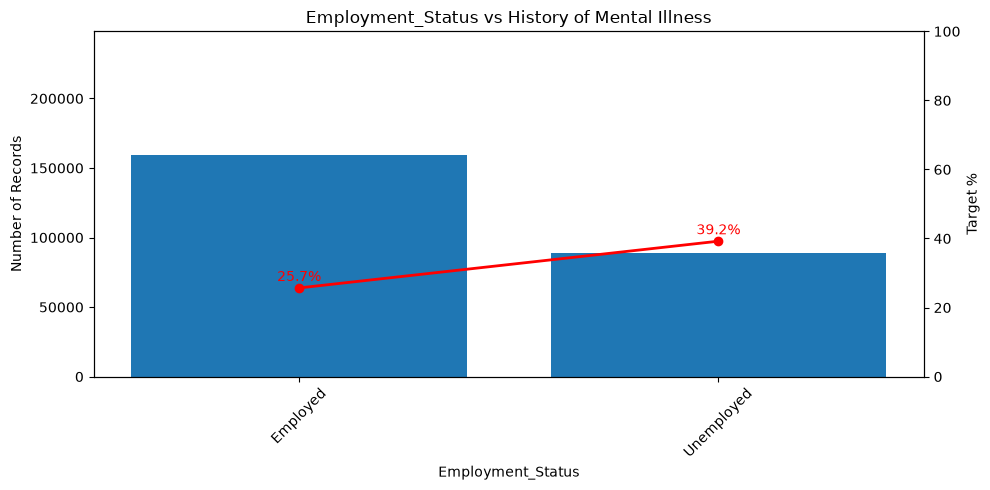

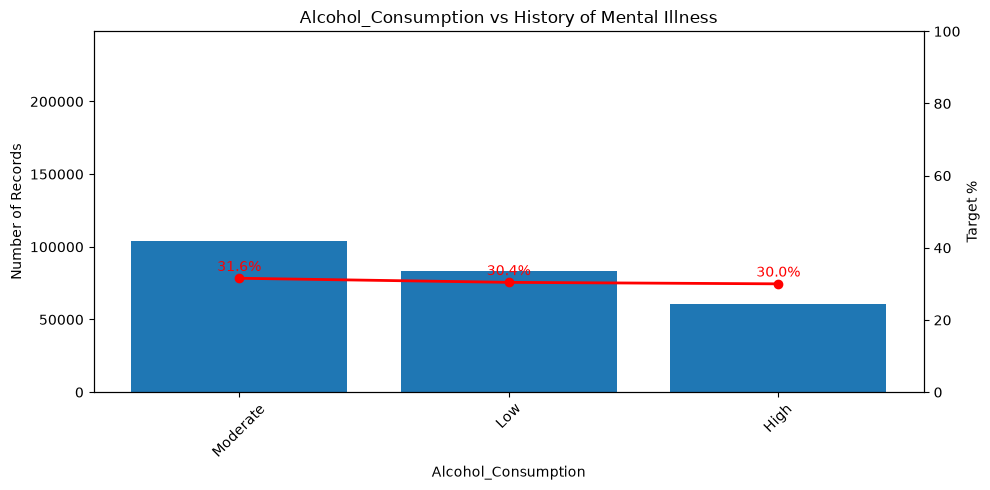

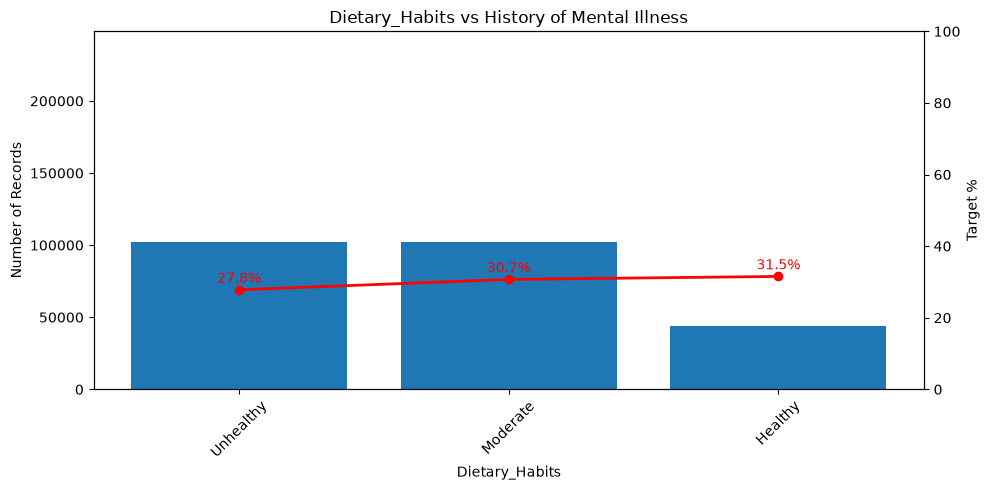

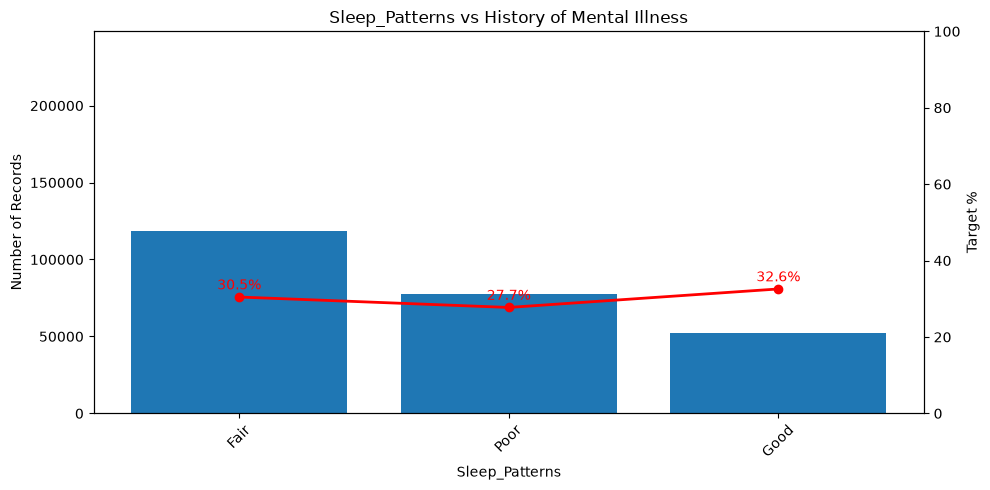

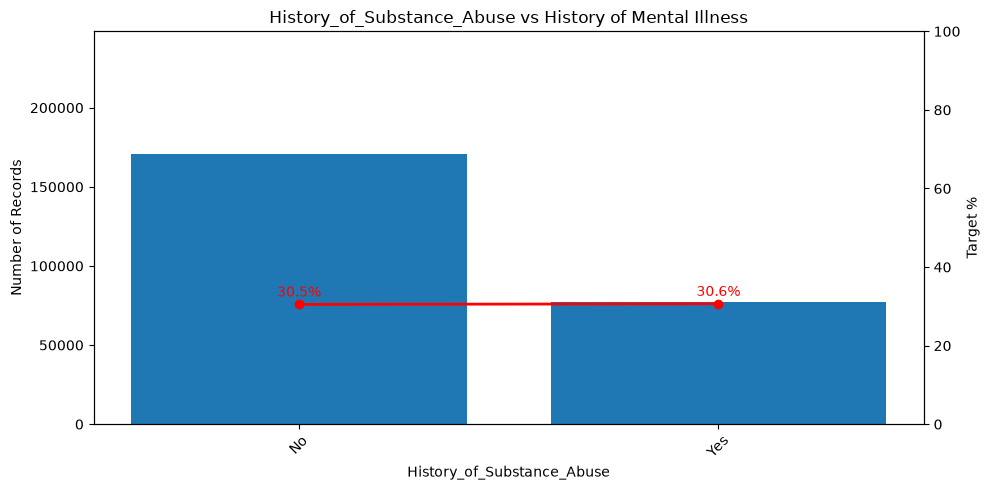

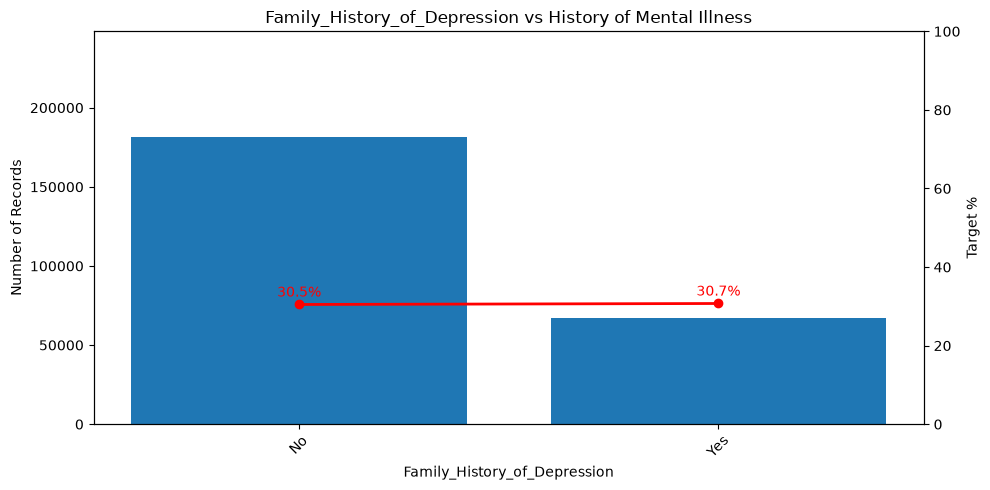

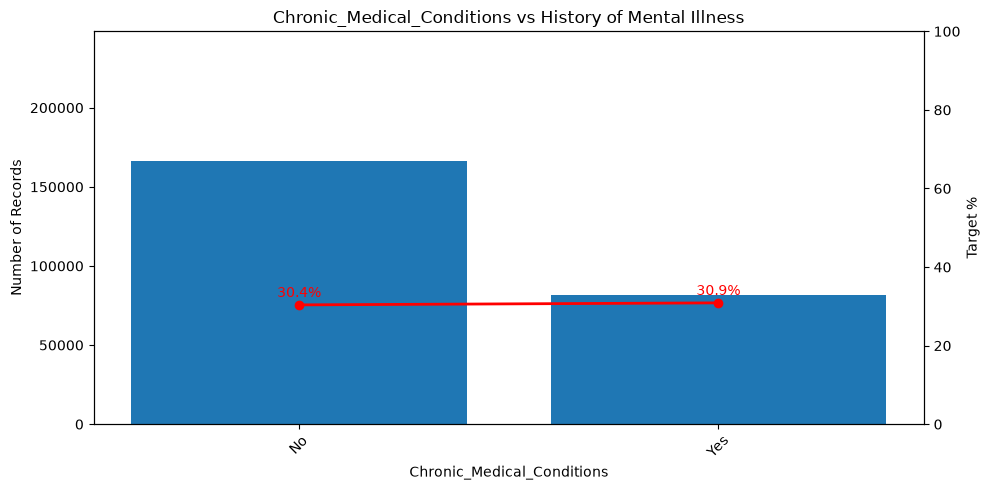

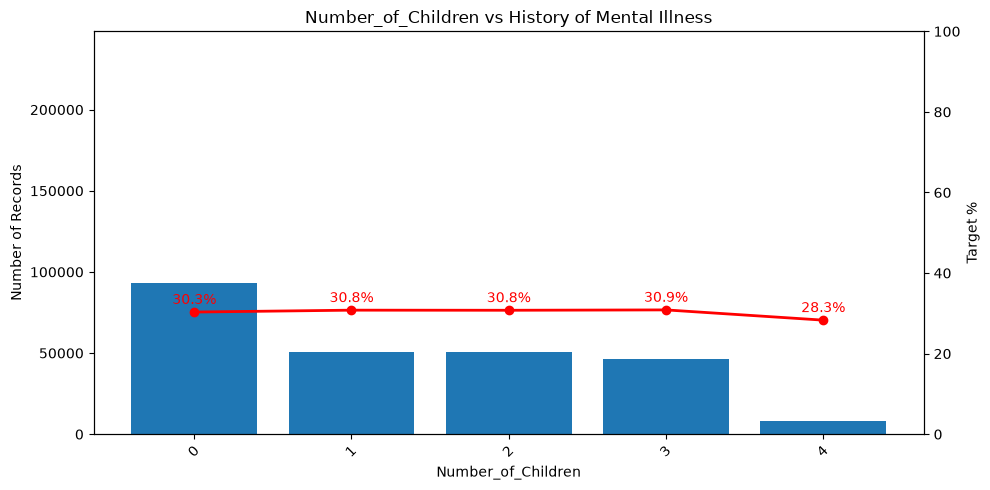

In [68]:
for feature in categorical_features:
    category_counts = df[df["data_split"] == "train"][feature].value_counts()

    target_rate = (
        df[df["data_split"] == "train"]
        .groupby(feature)["History_of_Mental_Illness"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(category_counts.index, category_counts.values)

    ax1.set_xlabel(feature)
    ax1.set_ylabel("Number of Records")
    ax1.tick_params(axis="x", rotation=45)
    ax1.set_ylim(0, 248256)

    ax2 = ax1.twinx()
    ax2.plot( category_counts.index, target_rate.values, marker="o", linewidth=2, color='red')
    ax2.set_ylabel("Target %")
    ax2.set_ylim(0, 100)

    for i, value in enumerate(target_rate.values):
        ax2.text(i, value + 2, f"{value:.1f}%", ha="center", color='red')

    plt.title(f"{feature} vs History of Mental Illness")
    plt.tight_layout()
    plt.show()

## Load split data into data folder

In [79]:
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/mental_health_data.csv", index=False)